In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/Dev/Documents/resume/Project for resume/EDA Project/Bank Customer Churn Analysis/Data/Churn_Modelling.csv")

In [3]:
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [4]:
print(df.shape)

(10000, 14)


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [6]:
print(df.describe())

         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.00000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584        0.499797   
min         0.000000     

In [7]:
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [8]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

In [9]:
print(df["Exited"].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


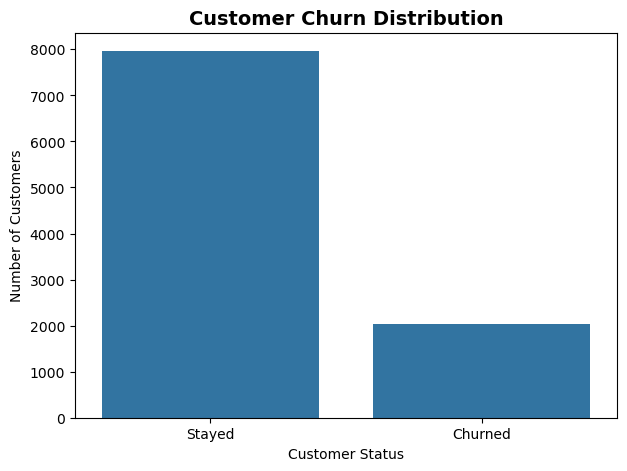

In [10]:
# 1. CUSTOMER CHURN DISTRIBUTION
plt.figure(figsize=(7,5))

sns.countplot(x="Exited", data=df)

plt.title("Customer Churn Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.xticks([0,1], ["Stayed", "Churned"])

plt.show()

* Majority customers stayed
* Around 20% churned
* Churn still significant for business

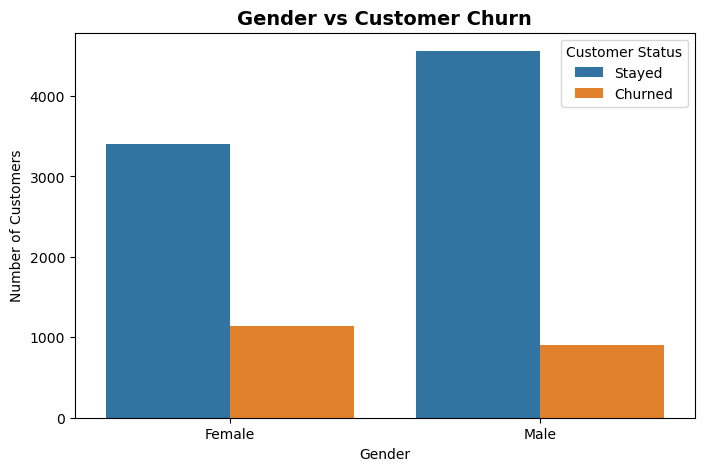

In [11]:
# 2. GENDER VS CHURN
plt.figure(figsize=(8,5))

sns.countplot(x="Gender", hue="Exited", data=df)

plt.title("Gender vs Customer Churn", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.legend(title="Customer Status",
           labels=["Stayed", "Churned"])

plt.show()

* Female customers show slightly higher churn
* Gender may influence retention behavior

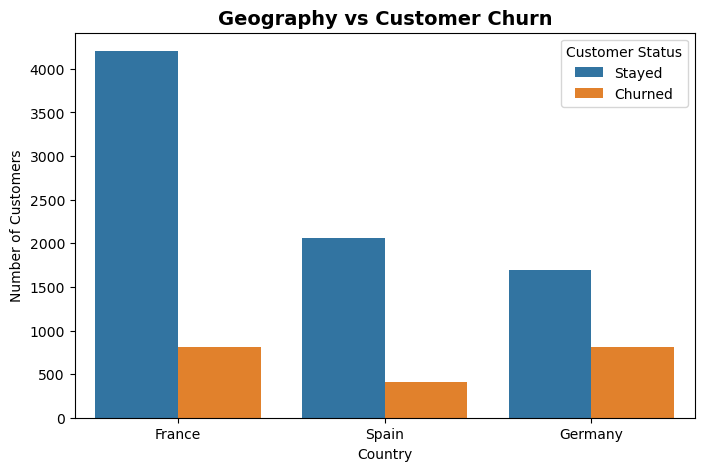

In [12]:
# 3. GEOGRAPHY VS CHURN
plt.figure(figsize=(8,5))

sns.countplot(x="Geography", hue="Exited", data=df)

plt.title("Geography vs Customer Churn", fontsize=14, fontweight='bold')
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.legend(title="Customer Status",
           labels=["Stayed", "Churned"])

plt.show()

* Germany has highest churn
* France has lowest churn

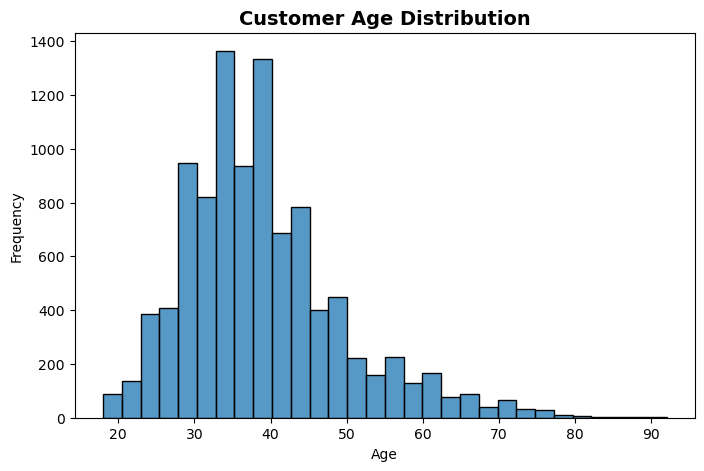

In [13]:
# 4. AGE DISTRIBUTION
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30)

plt.title("Customer Age Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

* Most customers are between 30–45 years old
* Older customers churn more

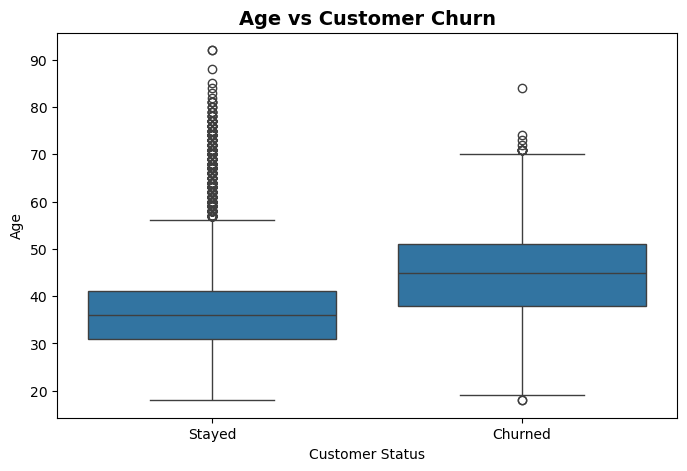

In [14]:
# 5. AGE VS CHURN

plt.figure(figsize=(8,5))

sns.boxplot(x="Exited", y="Age", data=df)

plt.title("Age vs Customer Churn", fontsize=14, fontweight='bold')
plt.xlabel("Customer Status")
plt.ylabel("Age")

plt.xticks([0,1], ["Stayed", "Churned"])

plt.show()


* Inactive customers churn significantly more
* Engagement strongly affects retention

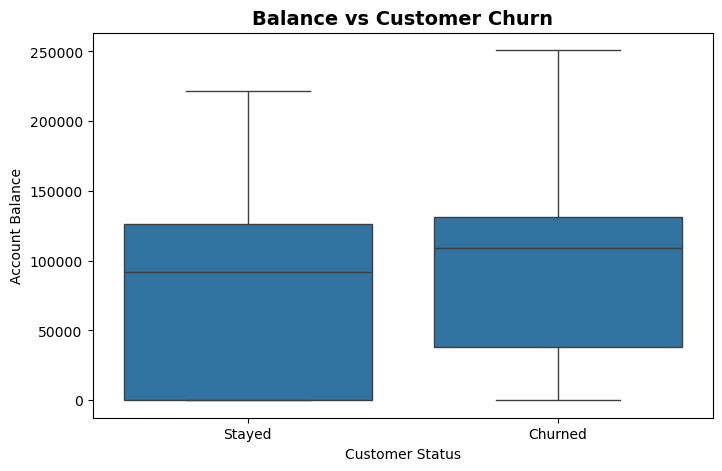

In [15]:
# 6. BALANCE VS CHURN

plt.figure(figsize=(8,5))

sns.boxplot(x="Exited", y="Balance", data=df)

plt.title("Balance vs Customer Churn", fontsize=14, fontweight='bold')
plt.xlabel("Customer Status")
plt.ylabel("Account Balance")

plt.xticks([0,1], ["Stayed", "Churned"])

plt.show()

* Customers with higher balances tend to churn more.
* High-value customers may require better retention strategies.
* Balance may be an important churn indicator.

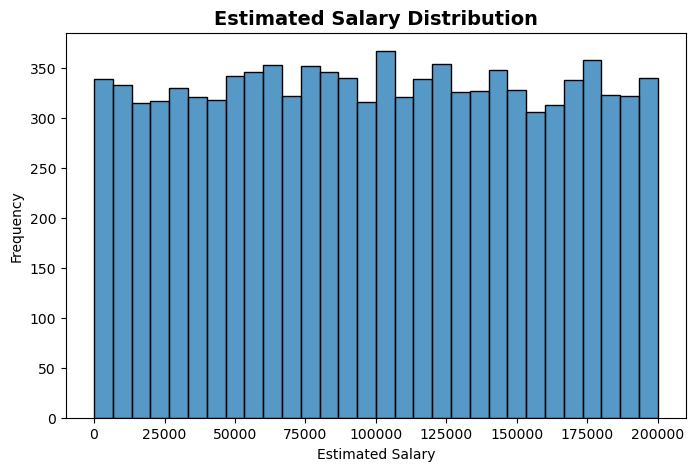

In [16]:
# 7. SALARY DISTRIBUTION

plt.figure(figsize=(8,5))

sns.histplot(df["EstimatedSalary"], bins=30)

plt.title("Estimated Salary Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Estimated Salary")
plt.ylabel("Frequency")

plt.show()


* Customer salaries are evenly distributed.
* Salary alone may not strongly impact churn.
* Customers from multiple income groups use the bank services.

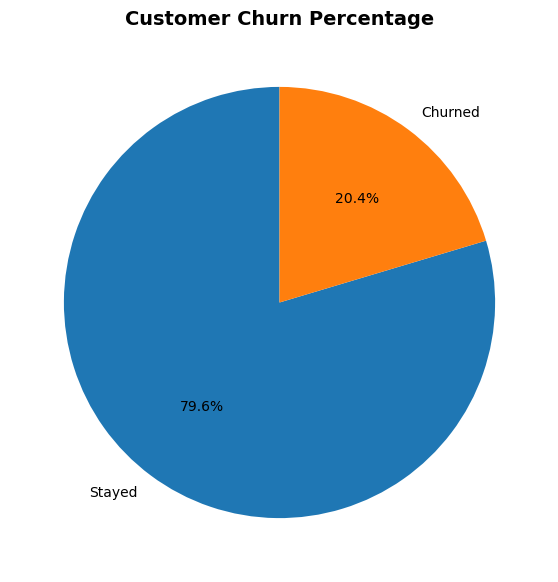

In [17]:
# 8. PRODUCTS VS CHURN RATE
churn_counts = df["Exited"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(churn_counts,
        labels=["Stayed", "Churned"],
        autopct='%1.1f%%',
        startangle=90)

plt.title("Customer Churn Percentage",
          fontsize=14,
          fontweight='bold')

plt.show()

* Customers with fewer products show higher churn rates.
* Multi-product customers appear more loyal.
* Increasing product usage may improve customer retention.

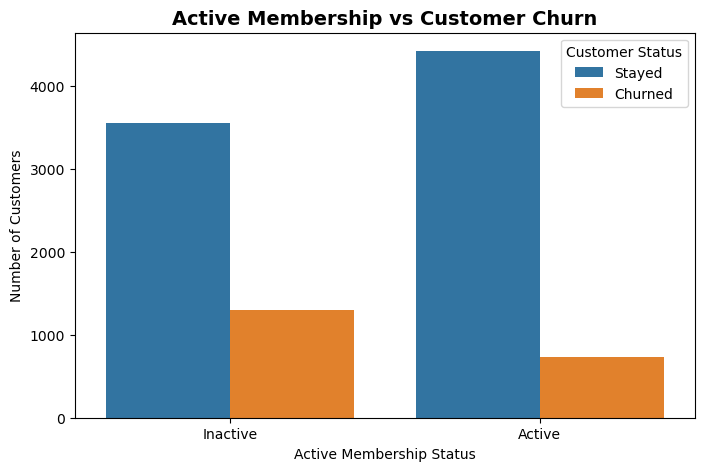

In [18]:
# 9. ACTIVE MEMBER VS CHURN

plt.figure(figsize=(8,5))

sns.countplot(x="IsActiveMember",
              hue="Exited",
              data=df)

plt.title("Active Membership vs Customer Churn",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Active Membership Status")
plt.ylabel("Number of Customers")

plt.xticks([0,1], ["Inactive", "Active"])

plt.legend(title="Customer Status",
           labels=["Stayed", "Churned"])

plt.show()

* Inactive customers churn significantly more.
* Active members are more likely to stay with the bank.
* Customer engagement plays a major role in retention.

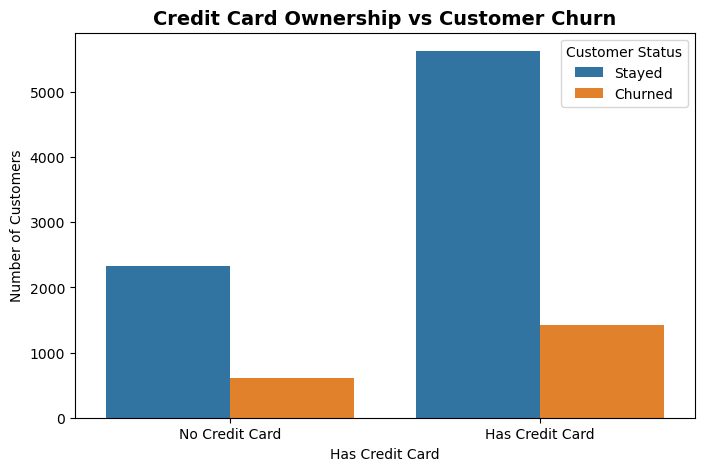

In [19]:
# 10. CREDIT CARD VS CHURN

plt.figure(figsize=(8,5))

sns.countplot(x="HasCrCard",
              hue="Exited",
              data=df)

plt.title("Credit Card Ownership vs Customer Churn",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Has Credit Card")
plt.ylabel("Number of Customers")

plt.xticks([0,1], ["No Credit Card", "Has Credit Card"])

plt.legend(title="Customer Status",
           labels=["Stayed", "Churned"])

plt.show()


* Customers with and without credit cards show similar churn patterns.
* Credit card ownership alone may not strongly affect churn.
* Other customer factors likely influence retention more.

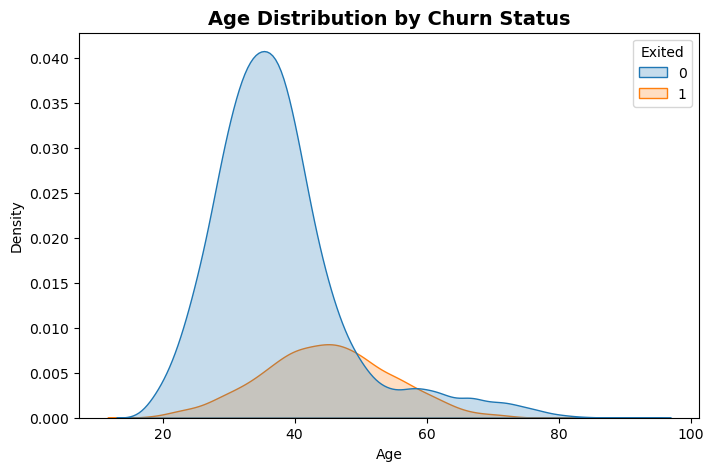

In [20]:
# 11. TENURE VS CHURN
plt.figure(figsize=(8,5))

sns.kdeplot(data=df,
            x="Age",
            hue="Exited",
            fill=True)

plt.title("Age Distribution by Churn Status",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Age")

plt.show()

* Customers with lower tenure show slightly higher churn.
* Long-term customers are generally more loyal.
* Building long-term relationships may reduce churn.

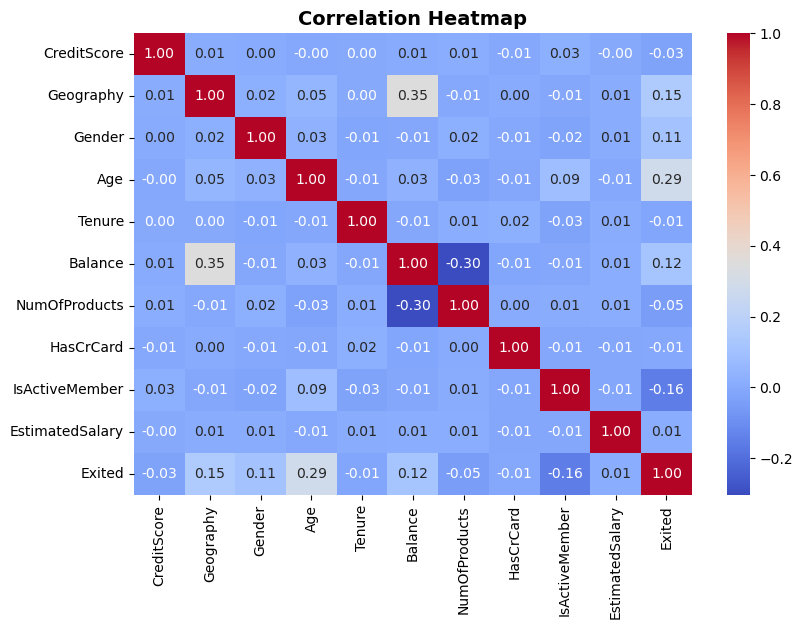

In [21]:
# 12. CORRELATION HEATMAP

# Convert categorical columns
df_encoded = df.copy()

df_encoded["Gender"] = df_encoded["Gender"].map({
    "Male": 0,
    "Female": 1
})

df_encoded["Geography"] = df_encoded["Geography"].map({
    "France": 0,
    "Spain": 1,
    "Germany": 2
})

plt.figure(figsize=(9,6))

sns.heatmap(df_encoded.corr(),
            annot=True,
            fmt=".2f",
            cmap="coolwarm")

plt.title("Correlation Heatmap",
          fontsize=14,
          fontweight='bold')

plt.show()

* Age has a positive correlation with churn.
* Active membership has a negative correlation with churn.
* No single variable completely explains customer churn.
* Churn is influenced by multiple customer factors.

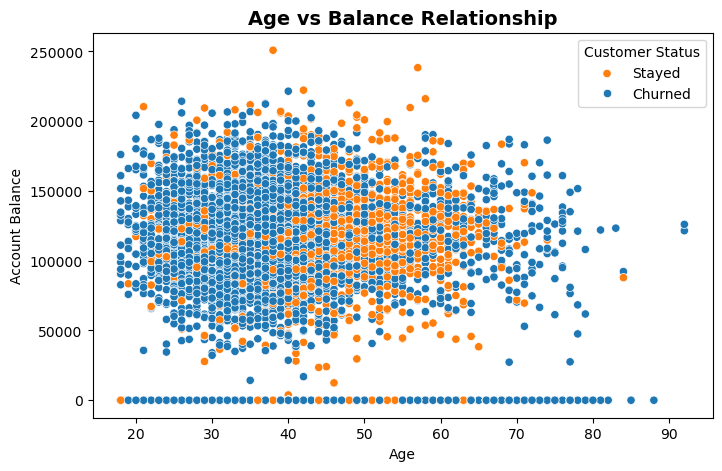

In [22]:
# 13. AGE VS BALANCE SCATTERPLOT

plt.figure(figsize=(8,5))

sns.scatterplot(x="Age",
                y="Balance",
                hue="Exited",
                data=df)

plt.title("Age vs Balance Relationship",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Age")
plt.ylabel("Account Balance")

plt.legend(title="Customer Status",
           labels=["Stayed", "Churned"])

plt.show()

* Older customers generally maintain higher account balances.
* Churned customers are more visible in higher age groups.
* Age and balance together may help identify high-risk customers.

In [23]:
# Check datatype
print(df["Balance"].dtype)

# Force numeric conversion
df["Balance"] = pd.to_numeric(df["Balance"], errors="coerce")

# Check again
print(df["Balance"].head())

float64
0         0.00
1     83807.86
2    159660.80
3         0.00
4    125510.82
Name: Balance, dtype: float64


In [25]:
df.to_csv("cleaned_churn_data.csv", index=False)